In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

In [2]:
class LoRA(nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()

        self.A = nn.Parameter(
            torch.randn(in_dim, rank) * 0.01
        )
        self.B = nn.Parameter(
            torch.zeros(rank, out_dim)
        )
        self.alpha = alpha
        self.rank = rank

    def forward(self, x):
        x = (self.alpha / self.rank )* (x @ self.A @ self.B)
        return x



#### The reason of multiplying the matrix A with 0.01(Std) is to control the scale of random values. Bcoz raw random numbers may be too large, Large values can make too large initially.But LoRA wants small updates initially  

In [3]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()


        self.fc1 = nn.Linear(1, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 32)
        self.fc3 = nn.Linear(32, 1)
        
    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [4]:
model = SimpleModel()

In [5]:
# Random data for trainning
x_train = torch.randn(1000,1)

y_train = 2*x_train + 1

In [6]:
# Normal Trainning of the model
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []

for epoch in range(100):

    pred = model(x_train)

    loss = criterion(pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} Loss: {loss.item():.4f}")

Epoch: 0 Loss: 4.4396
Epoch: 20 Loss: 0.4603
Epoch: 40 Loss: 0.0331
Epoch: 60 Loss: 0.0099
Epoch: 80 Loss: 0.0027


In [7]:
torch.save(model.state_dict(), 'pretrained.pth')
# Saved pretrained model

In [8]:
x_new = torch.randn(1000, 1)

y_new = 3 * x_new - 2
# New data for fine tunning

In [9]:

# First we will see Params required for complete Fine Tunning -> SO for that we will fine tunning the complete code of the model on the new data
full_model = SimpleModel()

full_model.load_state_dict(torch.load('pretrained.pth'))


optimizer_full = torch.optim.Adam(
    full_model.parameters(),
    lr=0.01
)

full_losses = []

for epoch in range(100):

    pred = full_model(x_new)

    loss = criterion(pred, y_new)

    optimizer_full.zero_grad()

    loss.backward()

    optimizer_full.step()

    full_losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"[FULL FT] Epoch: {epoch} Loss: {loss.item():.4f}")



[FULL FT] Epoch: 0 Loss: 9.7911
[FULL FT] Epoch: 20 Loss: 0.3595
[FULL FT] Epoch: 40 Loss: 0.0623
[FULL FT] Epoch: 60 Loss: 0.0426
[FULL FT] Epoch: 80 Loss: 0.0209


In [10]:
class LoRA(nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()

        self.A = nn.Parameter(
            torch.randn(in_dim, rank) * 0.01
        )
        self.B = nn.Parameter(
            torch.zeros(rank, out_dim)
        )
        self.alpha = alpha
        self.rank = rank

    def forward(self, x):
        x = (self.alpha / self.rank )* (x @ self.A @ self.B)
        return x



In [11]:

# Now we will Fine Tunning using LoRA 

class LoRAModel(nn.Module):

    def __init__(self, in_dim, out_dim, rank, alpha):

        super().__init__()

        self.fc1 = nn.Linear(1,16)
        self.lora1 = LoRA(1, 16, rank, alpha)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(16,32)
        self.lora2 = LoRA(16, 32, rank, alpha)
        
        self.fc3 = nn.Linear(32,1)
        self.lora3 = LoRA(32, 1, rank, alpha)

        for param in self.fc1.parameters():
            param.requires_grad = False

        for param in self.fc2.parameters():
            param.requires_grad = False

        for param in self.fc3.parameters():
            param.requires_grad = False

    def forward(self, x):

        x = self.fc1(x) + self.lora1(x)
        x = self.relu(x)
        x = self.fc2(x) + self.lora2(x)
        x = self.relu(x)
        x = self.fc3(x) + self.lora3(x)

        return x

In [12]:
lora_model = LoRAModel(1,1,8,16)


In [ ]:

pretrained = SimpleModel()

pretrained.load_state_dict(
    torch.load("pretrained.pth")
)

# Coping values from pretrained one
lora_model.fc1.weight.data.copy_(
    pretrained.fc1.weight.data
)
lora_model.fc1.bias.data.copy_(
    pretrained.fc1.bias.data
)

lora_model.fc2.weight.data = \
    pretrained.fc2.weight.data.clone()

lora_model.fc2.bias.data = \
    pretrained.fc2.bias.data.clone()

lora_model.fc3.weight.data = \
    pretrained.fc3.weight.data.clone()

lora_model.fc3.bias.data = \
    pretrained.fc3.bias.data.clone()

In [14]:
print("\nTrainable Parameters:\n")

for name, param in lora_model.named_parameters():

    print(name, param.requires_grad)


Trainable Parameters:

fc1.weight False
fc1.bias False
lora1.A True
lora1.B True
fc2.weight False
fc2.bias False
lora2.A True
lora2.B True
fc3.weight False
fc3.bias False
lora3.A True
lora3.B True


In [15]:
total_params_full = sum(
    p.numel()
    for p in full_model.parameters()
)

trainable_params_full = sum(
    p.numel()
    for p in full_model.parameters()
    if p.requires_grad
)

print("FULL FINETUNING")

print(f"Total Params: {total_params_full}")

print(f"Trainable Params: {trainable_params_full}")

FULL FINETUNING
Total Params: 609
Trainable Params: 609


In [16]:
total_params = sum(
    p.numel() for p in lora_model.parameters()
)
trainable_params = sum(
    p.numel()
    for p in lora_model.parameters()
    if p.requires_grad
)

print(f"\Total   Params: {total_params}")
print(f"\nLoRA Trainable Params: {trainable_params}")

\Total   Params: 1393

LoRA Trainable Params: 784


<>:10: SyntaxWarning: invalid escape sequence '\T'
<>:10: SyntaxWarning: invalid escape sequence '\T'
C:\Users\OM CHIDDARWAR\AppData\Local\Temp\ipykernel_22344\1886560173.py:10: SyntaxWarning: invalid escape sequence '\T'
  print(f"\Total   Params: {total_params}")


In [17]:
optimizer_lora = torch.optim.Adam(

    filter(
        lambda p: p.requires_grad,
        lora_model.parameters()
    ),

    lr=0.01
)

lora_losses = []

for epoch in range(100):

    pred = lora_model(x_new)

    loss = criterion(pred, y_new)

    optimizer_lora.zero_grad()

    loss.backward()

    optimizer_lora.step()

    lora_losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"[LORA] Epoch: {epoch} Loss: {loss.item():.4f}")



[LORA] Epoch: 0 Loss: 9.7911
[LORA] Epoch: 20 Loss: 0.6217
[LORA] Epoch: 40 Loss: 0.1353
[LORA] Epoch: 60 Loss: 0.0512
[LORA] Epoch: 80 Loss: 0.0210


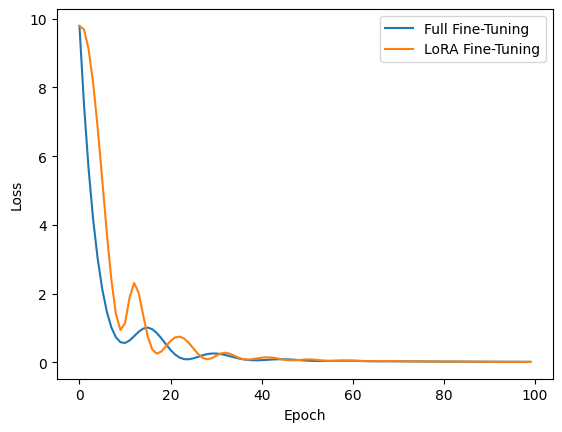

In [18]:
import matplotlib.pyplot as plt
plt.plot(full_losses, label="Full Fine-Tuning")

plt.plot(lora_losses, label="LoRA Fine-Tuning")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [19]:
test_x = torch.tensor([[2.0]])

print("\nExpected Value:")
print(3 * 2 - 2)

print("\nFull FT Prediction:")
print(full_model(test_x).item())

print("\nLoRA Prediction:")
print(lora_model(test_x).item())


Expected Value:
4

Full FT Prediction:
3.856060266494751

LoRA Prediction:
3.861675977706909
